# Laboratorio 2 — Análisis de Datos

Notebook para generar los gráficos de señales utilizando el mapa simple para las mediciones en README.md.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.grid'] = True

OUTPUT_DIR = Path("graficos")
OUTPUT_DIR.mkdir(exist_ok=True)

log_dir = Path("../logs")
csv_files = glob.glob(str(log_dir / "*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No se encontraron CSVs en {log_dir.resolve()}")

latest_file = max(csv_files, key=os.path.getmtime)
print(f"Cargando: {latest_file}")
df = pd.read_csv(latest_file, comment='#')

# Ventana de analisis (segundos)
START_TIME = 0
WINDOW_SECONDS = 600
END_TIME = START_TIME + WINDOW_SECONDS

if 'time_s' not in df.columns:
    raise KeyError("No existe la columna time_s en el CSV")

df_window = df[(df['time_s'] >= START_TIME) & (df['time_s'] <= END_TIME)].copy()
print(f"Datos totales: {len(df)} filas, ventana {START_TIME}-{END_TIME}s: {len(df_window)} filas")
display(df_window.head())

Cargando: ../logs/lab2_kalman_20260521_213919.csv
Datos totales: 30950 filas, ventana 0-600s: 18751 filas


,k,time_s,Ts_s,fs_Hz,state,turn_dir,turn_travelled_wheel_rad,turn_target_wheel_rad,backup_remaining,enc_left_rad,...,front_left_m,front_right_m,front_raw_m,front_ema_m,front_kalman_m,front_used_m,side_left_m,side_right_m,side_left_raw,side_right_raw
0,0,0.000,0.032,31.25,FORWARD,NaN,0.0,1.992229,0,12.80492,...,0.196754,0.197047,0.196754,0.196754,0.196754,0.196754,0.196684,0.196765,71.485571,69.729024
1,1,0.032,0.032,31.25,FORWARD,NaN,0.0,1.992229,0,12.91168,...,0.196889,0.196855,0.196855,0.196779,0.195635,0.195635,0.196742,0.196673,70.236257,71.729115
2,2,0.064,0.032,31.25,FORWARD,NaN,0.0,1.992229,0,13.02472,...,0.196983,0.196769,0.196769,0.196777,0.194513,0.194513,0.196765,0.196911,69.746300,66.597163
3,3,0.096,0.032,31.25,FORWARD,NaN,0.0,1.992229,0,13.13148,...,0.196716,0.197086,0.196716,0.196761,0.193425,0.193425,0.196842,0.196890,68.080248,67.041813
4,4,0.128,0.032,31.25,FORWARD,NaN,0.0,1.992229,0,13.24452,...,0.196988,0.196625,0.196625,0.196727,0.192370,0.192370,0.196529,0.196806,74.827764,68.852901


In [2]:
if 'df' in locals() and 'time_s' in df.columns:
    time_s = df['time_s'].to_numpy()
    if time_s.size > 1:
        dt = np.diff(time_s)
        ts_med = float(np.median(dt))
        ts_mean = float(np.mean(dt))
        fs_hz = 1.0 / ts_med if ts_med > 0 else float('nan')
        duration_s = float(time_s[-1] - time_s[0])
        n_samples = len(df)
        print(f"Ts mediana: {ts_med:.4f} s (media {ts_mean:.4f} s), fs ~ {fs_hz:.2f} Hz")
        print(f"Muestras: {n_samples}, duracion: {duration_s:.1f} s")
        print(f"dt min/max: {dt.min():.4f}/{dt.max():.4f} s")
    if 'state' in df.columns:
        counts = df['state'].value_counts()
        print("Estados:", ", ".join(f"{k}={v}" for k, v in counts.items()))

Ts mediana: 0.0320 s (media 0.0320 s), fs ~ 31.25 Hz
Muestras: 30950, duracion: 990.4 s
dt min/max: 0.0320/0.0320 s
Estados: FORWARD=25670, TURN=4128, BACKUP=1152


**Datos:** ver celda de resumen (Ts, fs, muestras, duracion).  
**Escenario:** mapa simple.  
**Ventana:** ver celda de carga (START_TIME/WINDOW_SECONDS).  
**Estados detectados:** FORWARD, BACKUP, TURN  
**Parametros:** alpha=0.25 (EMA), P0=0.05, Q=0.0001, R=0.005 (Kalman), umbral=0.18m

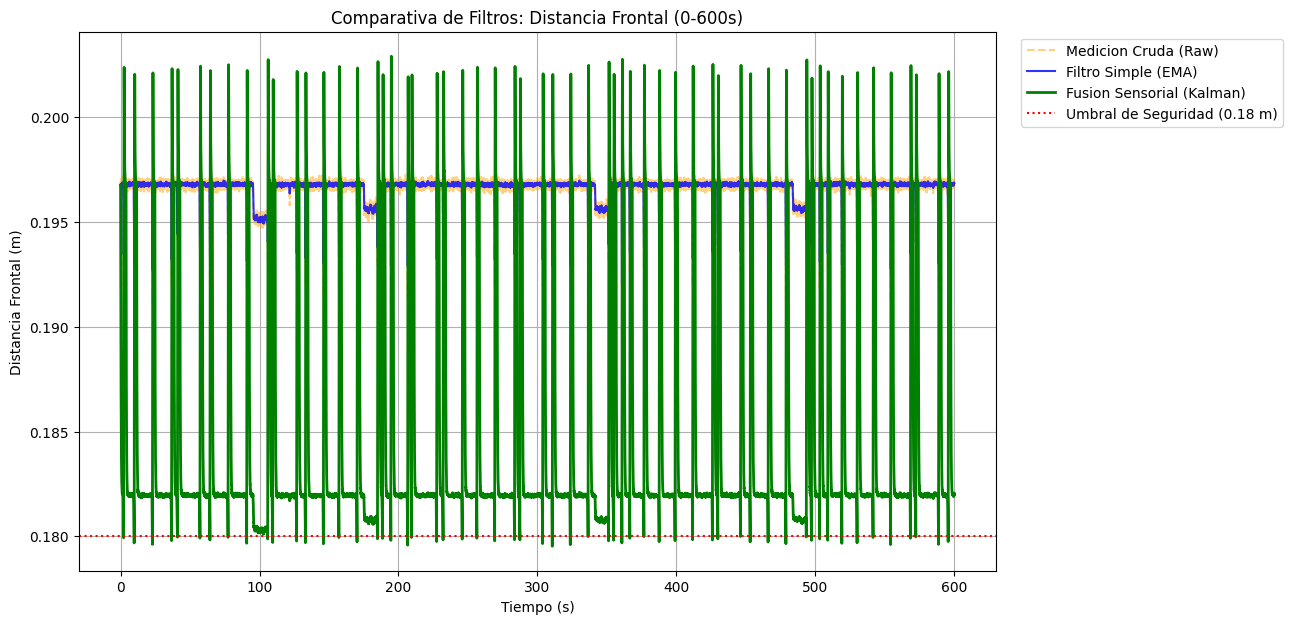

Grafico guardado: graficos/comparativa_filtros.png


In [3]:
if 'df_window' in locals() and 'time_s' in df_window.columns:
    plt.figure(figsize=(14, 7))

    plt.plot(df_window['time_s'], df_window['front_raw_m'], label='Medicion Cruda (Raw)', alpha=0.5, color='orange', linestyle='--')
    plt.plot(df_window['time_s'], df_window['front_ema_m'], label='Filtro Simple (EMA)', alpha=0.8, color='blue')
    plt.plot(df_window['time_s'], df_window['front_kalman_m'], label='Fusion Sensorial (Kalman)', alpha=1.0, color='green', linewidth=2)

    plt.axhline(y=0.18, color='red', linestyle=':', label='Umbral de Seguridad (0.18 m)')
    plt.title(f'Comparativa de Filtros: Distancia Frontal ({START_TIME}-{END_TIME}s)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia Frontal (m)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'comparativa_filtros.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'comparativa_filtros.png')

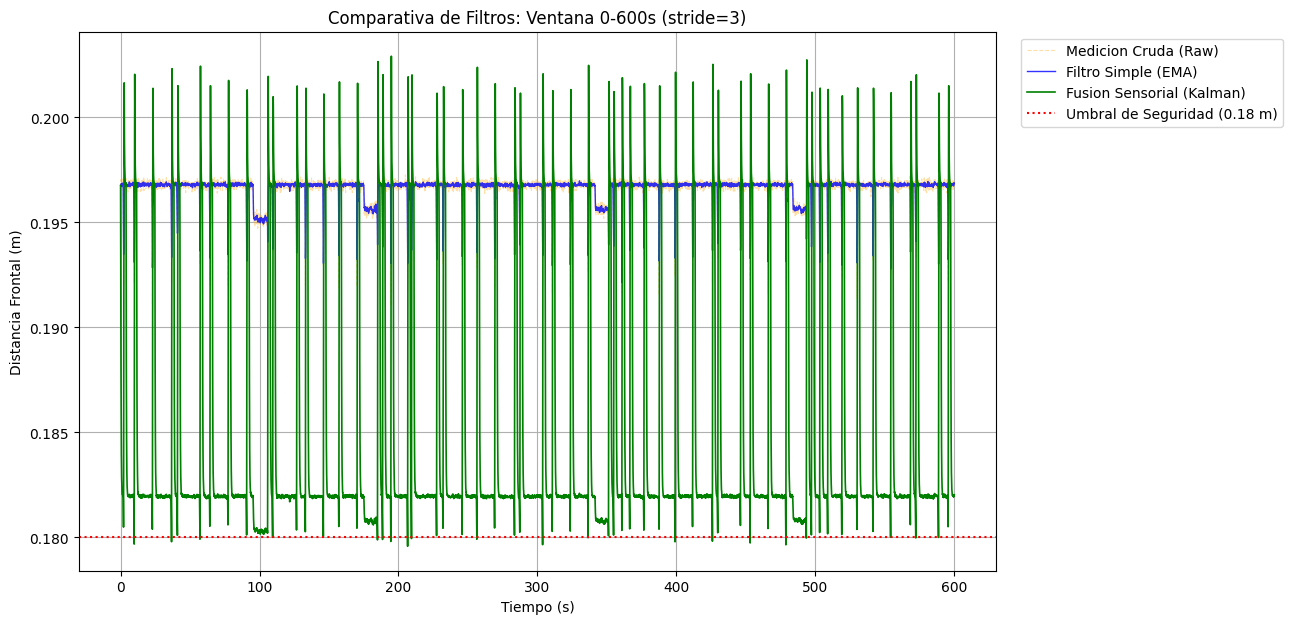

Grafico guardado: graficos/comparativa_filtros_full.png


In [4]:
if 'df' in locals() and 'time_s' in df.columns:
    df_long = df_window if 'df_window' in locals() else df
    max_points = 6000
    stride = max(1, len(df_long) // max_points)
    df_full = df_long.iloc[::stride]

    plt.figure(figsize=(14, 7))

    plt.plot(df_full['time_s'], df_full['front_raw_m'], label='Medicion Cruda (Raw)', alpha=0.35, color='orange', linestyle='--', linewidth=0.8)
    plt.plot(df_full['time_s'], df_full['front_ema_m'], label='Filtro Simple (EMA)', alpha=0.8, color='blue', linewidth=1.0)
    plt.plot(df_full['time_s'], df_full['front_kalman_m'], label='Fusion Sensorial (Kalman)', alpha=1.0, color='green', linewidth=1.2)

    plt.axhline(y=0.18, color='red', linestyle=':', label='Umbral de Seguridad (0.18 m)')
    plt.title(f'Comparativa de Filtros: Ventana {START_TIME}-{END_TIME}s (stride={stride})')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia Frontal (m)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'comparativa_filtros_full.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'comparativa_filtros_full.png')

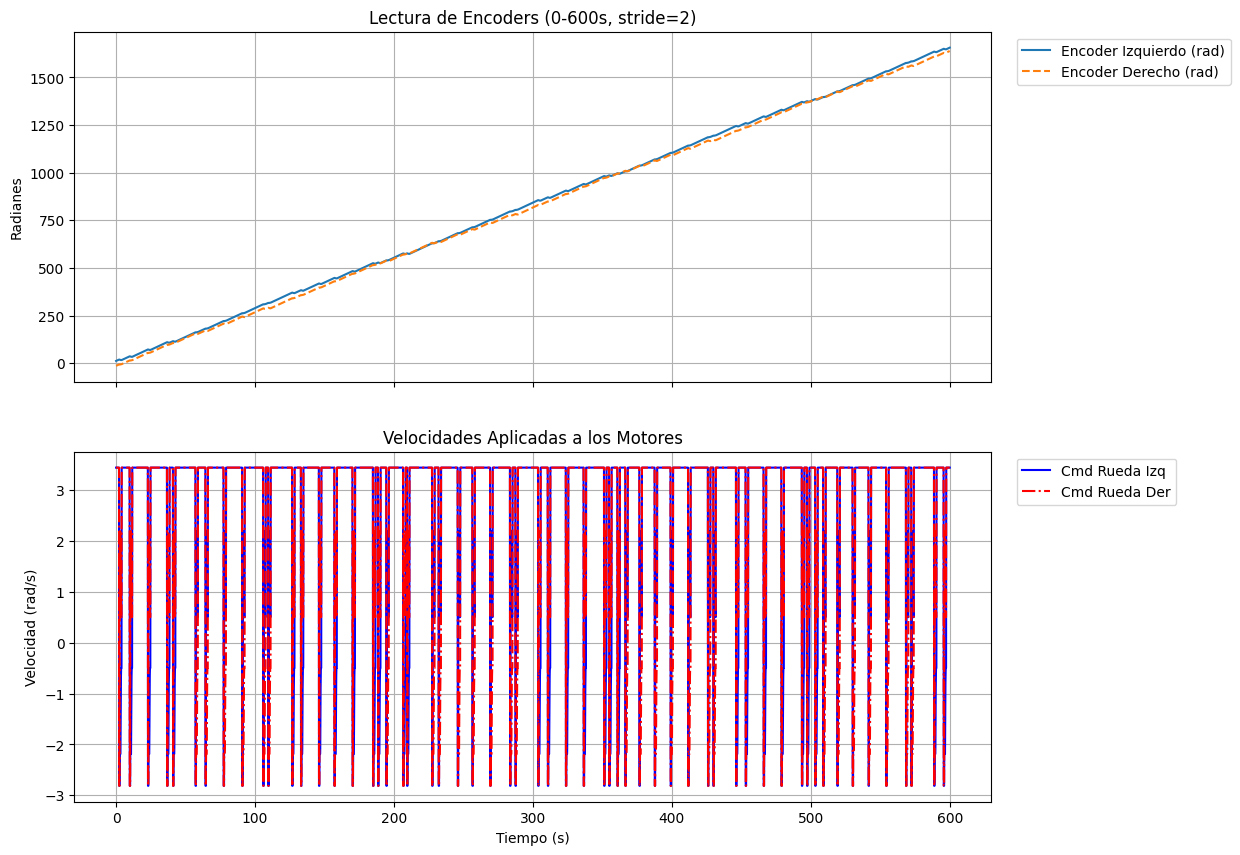

Grafico guardado: graficos/encoders_velocidades.png


In [5]:
if 'df_window' in locals() and 'time_s' in df_window.columns:
    max_points = 8000
    stride = max(1, len(df_window) // max_points)
    df_plot = df_window.iloc[::stride]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(df_plot['time_s'], df_plot['enc_left_rad'], label='Encoder Izquierdo (rad)', color='#1f77b4')
    ax1.plot(df_plot['time_s'], df_plot['enc_right_rad'], label='Encoder Derecho (rad)', color='#ff7f0e', linestyle='--')
    ax1.set_title(f'Lectura de Encoders ({START_TIME}-{END_TIME}s, stride={stride})')
    ax1.set_ylabel('Radianes')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax1.grid(True)

    ax2.plot(df_plot['time_s'], df_plot['cmd_left_vel'], label='Cmd Rueda Izq', color='blue')
    ax2.plot(df_plot['time_s'], df_plot['cmd_right_vel'], label='Cmd Rueda Der', color='red', linestyle='-.')
    ax2.set_title('Velocidades Aplicadas a los Motores')
    ax2.set_ylabel('Velocidad (rad/s)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.grid(True)

    fig.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'encoders_velocidades.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'encoders_velocidades.png')

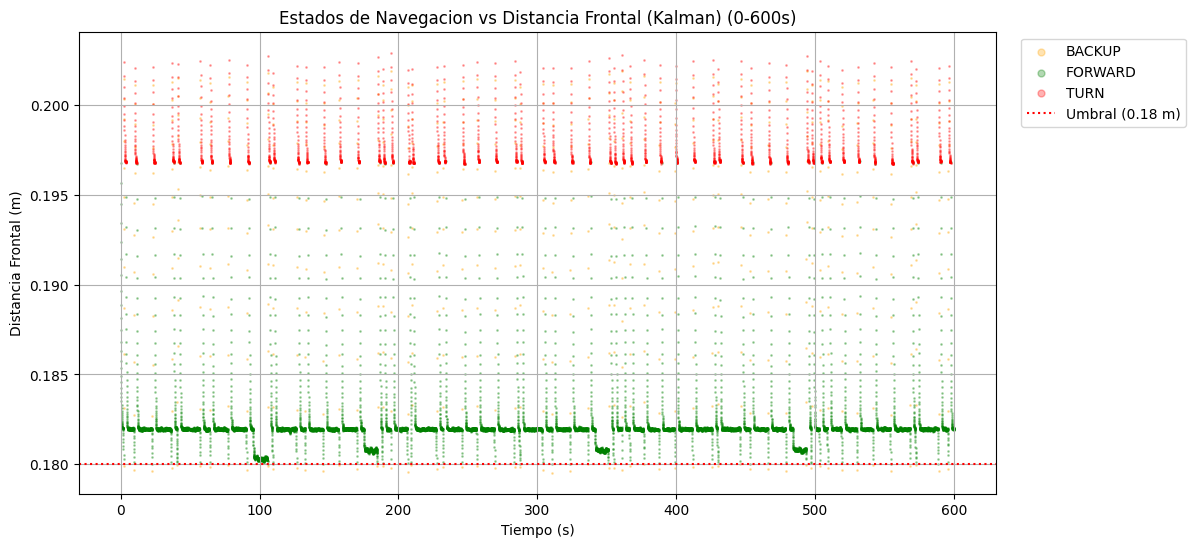

Grafico guardado: graficos/estados_navegacion.png


In [6]:
if 'df_window' in locals() and 'time_s' in df_window.columns:
    fig, ax = plt.subplots(figsize=(14, 6))

    colors = {'FORWARD': 'green', 'BACKUP': 'orange', 'TURN': 'red'}
    for state, group in df_window.groupby('state'):
        ax.scatter(group['time_s'], group['front_kalman_m'],
                   label=state, color=colors.get(state, 'gray'), s=1, alpha=0.3)

    plt.axhline(y=0.18, color='red', linestyle=':', label='Umbral (0.18 m)')
    plt.title(f'Estados de Navegacion vs Distancia Frontal (Kalman) ({START_TIME}-{END_TIME}s)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia Frontal (m)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=5)
    plt.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'estados_navegacion.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'estados_navegacion.png')

Archivos seleccionados por control_source:
  filtered: lab2_filtered_20260521_213815.csv
  kalman: lab2_kalman_20260521_213919.csv
  raw: lab2_raw_20260521_213655.csv


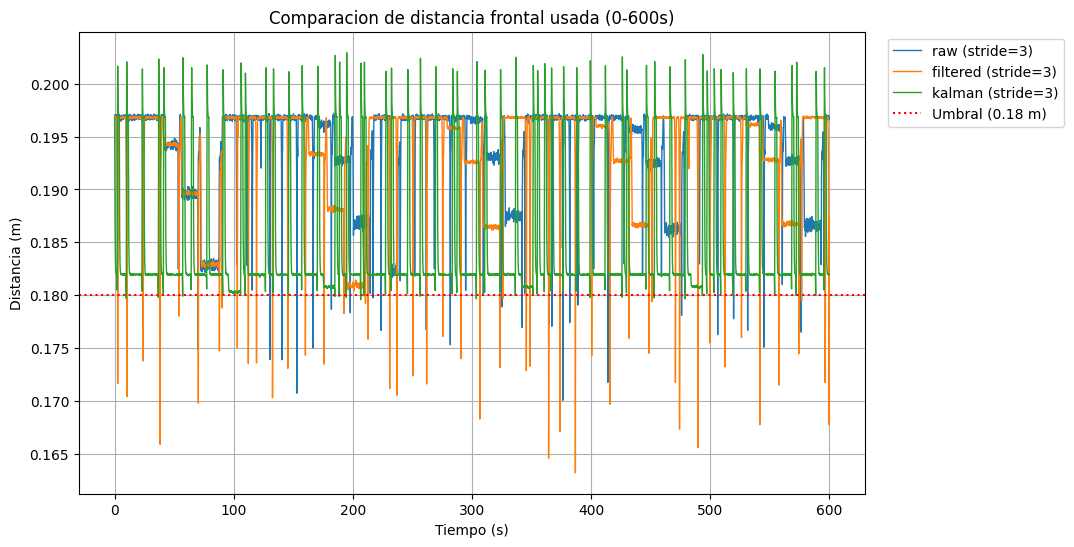

Grafico guardado: graficos/comparacion_front_used.png


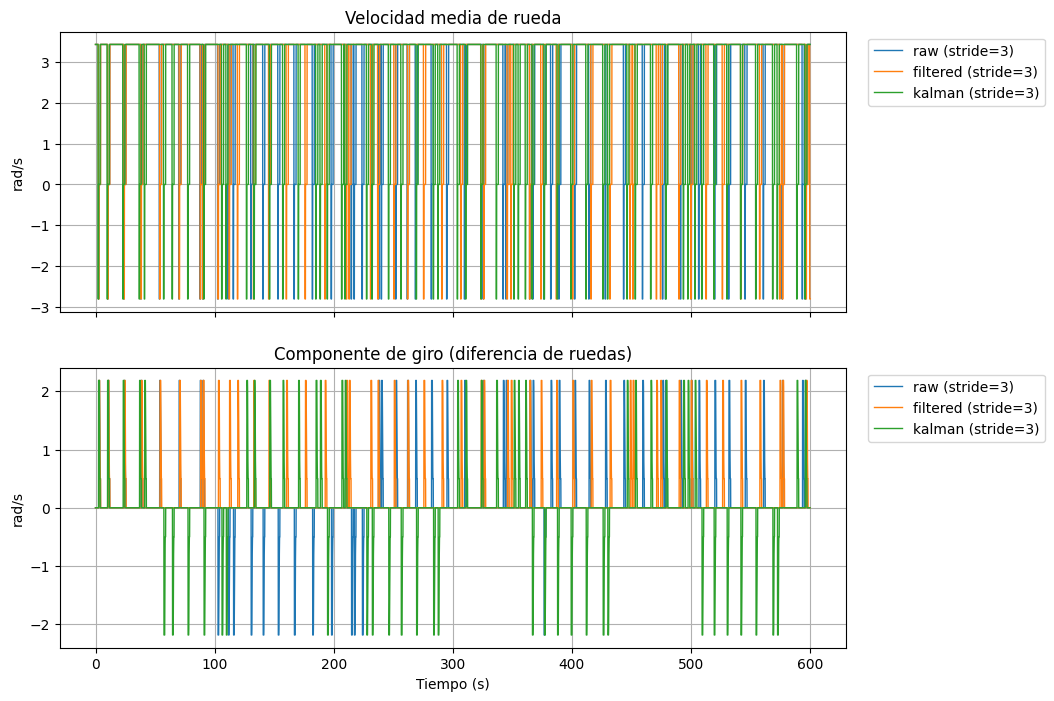

Grafico guardado: graficos/comparacion_cmd.png


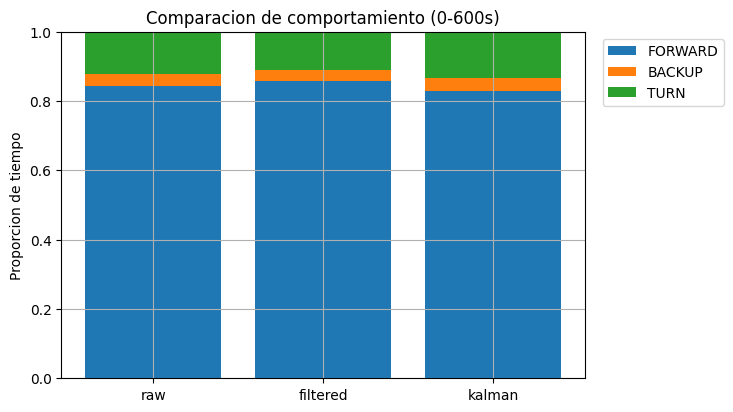

Grafico guardado: graficos/comparacion_comportamiento.png


In [7]:
source_files = {}
for path in log_dir.glob("*.csv"):
    control = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(5):
            line = f.readline()
            if not line:
                break
            if line.startswith("# control_source:"):
                control = line.split(":", 1)[1].strip()
                break
    if control:
        prev = source_files.get(control)
        if not prev or path.stat().st_mtime > prev.stat().st_mtime:
            source_files[control] = path

print("Archivos seleccionados por control_source:")
for k, v in source_files.items():
    print(f"  {k}: {v.name}")

sources = [s for s in ['raw', 'filtered', 'kalman'] if s in source_files]
if len(sources) >= 2:
    dfs = {src: pd.read_csv(source_files[src], comment='#') for src in sources}

    def downsample_df(df_in, max_points=6000):
        stride = max(1, len(df_in) // max_points)
        return df_in.iloc[::stride], stride

    def window_df(df_in):
        if 'time_s' not in df_in.columns:
            return df_in
        return df_in[(df_in['time_s'] >= START_TIME) & (df_in['time_s'] <= END_TIME)].copy()

    # 1) Comparacion de distancia frontal usada por el controlador
    fig, ax = plt.subplots(figsize=(12, 6))
    plotted = 0
    for src, df_src in dfs.items():
        df_src = window_df(df_src)
        if {'time_s', 'front_used_m'}.issubset(df_src.columns):
            df_plot, stride = downsample_df(df_src, 6000)
            ax.plot(df_plot['time_s'], df_plot['front_used_m'], label=f"{src} (stride={stride})", linewidth=1.0)
            plotted += 1

    if plotted:
        ax.axhline(y=0.18, color='red', linestyle=':', label='Umbral (0.18 m)')
        ax.set_title(f'Comparacion de distancia frontal usada ({START_TIME}-{END_TIME}s)')
        ax.set_xlabel('Tiempo (s)')
        ax.set_ylabel('Distancia (m)')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        fig.subplots_adjust(right=0.78)
        plt.savefig(OUTPUT_DIR / 'comparacion_front_used.png', dpi=150)
        plt.show()
        print("Grafico guardado:", OUTPUT_DIR / 'comparacion_front_used.png')
    else:
        print("No hay columnas front_used_m/time_s para comparar.")

    # 2) Comparacion de comandos (velocidad media y giro)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    plotted = 0
    for src, df_src in dfs.items():
        df_src = window_df(df_src)
        if {'time_s', 'cmd_left_vel', 'cmd_right_vel'}.issubset(df_src.columns):
            df_plot, stride = downsample_df(df_src, 6000)
            cmd_avg = (df_plot['cmd_left_vel'] + df_plot['cmd_right_vel']) / 2.0
            cmd_turn = (df_plot['cmd_right_vel'] - df_plot['cmd_left_vel']) / 2.0
            ax1.plot(df_plot['time_s'], cmd_avg, label=f"{src} (stride={stride})", linewidth=1.0)
            ax2.plot(df_plot['time_s'], cmd_turn, label=f"{src} (stride={stride})", linewidth=1.0)
            plotted += 1

    if plotted:
        ax1.set_title('Velocidad media de rueda')
        ax1.set_ylabel('rad/s')
        ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax1.grid(True)

        ax2.set_title('Componente de giro (diferencia de ruedas)')
        ax2.set_ylabel('rad/s')
        ax2.set_xlabel('Tiempo (s)')
        ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax2.grid(True)

        fig.subplots_adjust(right=0.78)
        plt.savefig(OUTPUT_DIR / 'comparacion_cmd.png', dpi=150)
        plt.show()
        print("Grafico guardado:", OUTPUT_DIR / 'comparacion_cmd.png')
    else:
        print("No hay columnas de comandos para comparar.")

    # 3) Comparacion de comportamiento por estados
    states = ['FORWARD', 'BACKUP', 'TURN']
    rows = []
    for src in sources:
        df_src = window_df(dfs[src])
        total = len(df_src)
        counts = df_src['state'].value_counts() if 'state' in df_src.columns else {}
        rows.append([counts.get(st, 0) / total if total else 0 for st in states])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(sources))
    bottom = np.zeros(len(sources))
    for i, st in enumerate(states):
        vals = [row[i] for row in rows]
        ax.bar(x, vals, bottom=bottom, label=st)
        bottom += vals

    ax.set_xticks(x, sources)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporcion de tiempo')
    ax.set_title(f'Comparacion de comportamiento ({START_TIME}-{END_TIME}s)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'comparacion_comportamiento.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'comparacion_comportamiento.png')
else:
    print("Se encontraron pocos control_source. Para comparar raw/filtered/kalman, ejecutar corridas con cada modo.")

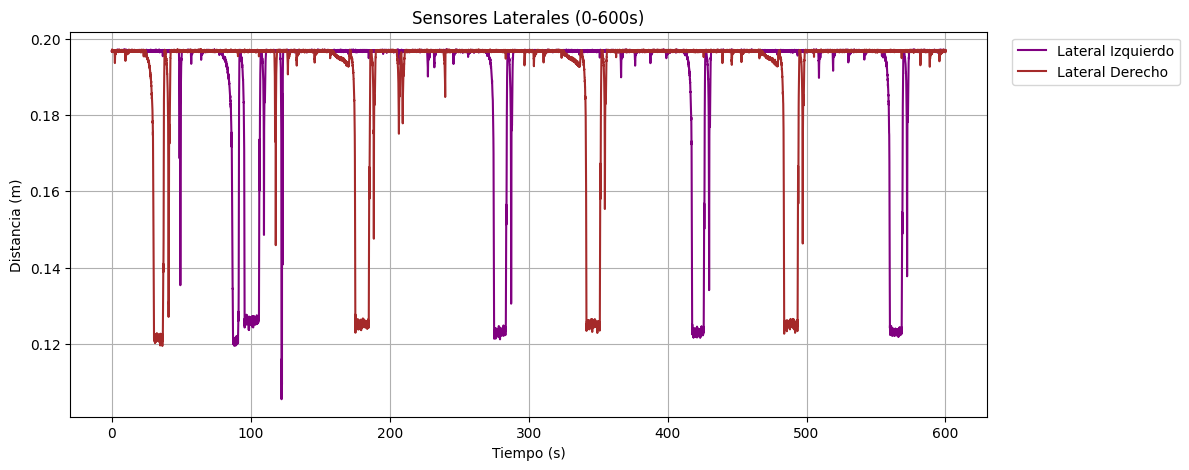

Grafico guardado: graficos/sensores_laterales.png


In [8]:
if 'df_window' in locals() and 'time_s' in df_window.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(df_window['time_s'], df_window['side_left_m'], label='Lateral Izquierdo', color='purple')
    plt.plot(df_window['time_s'], df_window['side_right_m'], label='Lateral Derecho', color='brown')
    plt.title(f'Sensores Laterales ({START_TIME}-{END_TIME}s)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia (m)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'sensores_laterales.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'sensores_laterales.png')

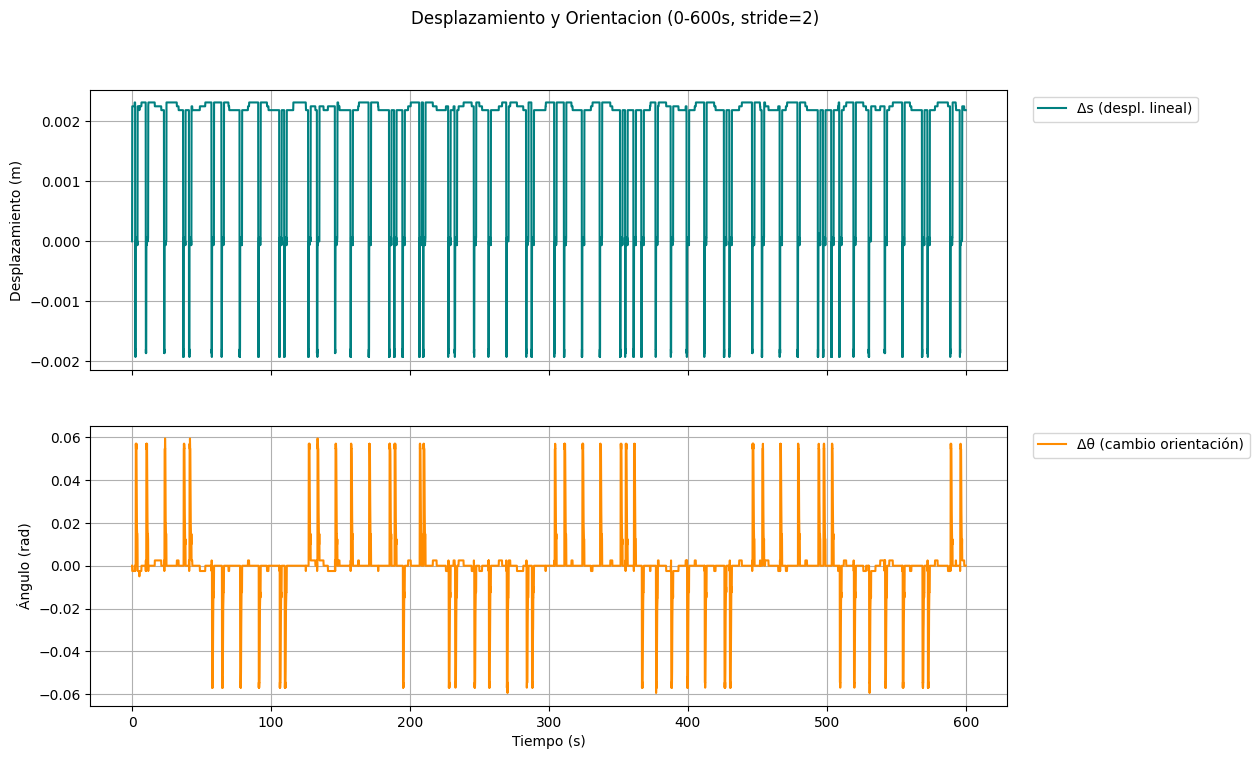

Grafico guardado: graficos/desplazamiento_encoders.png


In [9]:
if 'df_window' in locals() and 'time_s' in df_window.columns:
    max_points = 8000
    stride = max(1, len(df_window) // max_points)
    df_plot = df_window.iloc[::stride]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(df_plot['time_s'], df_plot['delta_s_m'], label='Δs (despl. lineal)', color='teal')
    ax1.set_ylabel('Desplazamiento (m)')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax1.grid(True)

    ax2.plot(df_plot['time_s'], df_plot['delta_theta_rad'], label='Δθ (cambio orientación)', color='darkorange')
    ax2.set_ylabel('Ángulo (rad)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.grid(True)

    plt.suptitle(f'Desplazamiento y Orientacion ({START_TIME}-{END_TIME}s, stride={stride})')
    fig.subplots_adjust(right=0.78)
    plt.savefig(OUTPUT_DIR / 'desplazamiento_encoders.png', dpi=150)
    plt.show()
    print("Grafico guardado:", OUTPUT_DIR / 'desplazamiento_encoders.png')